# GAIE — Generative AI For Engineering · Global Solution 2026/1 (Indústria Espacial)
## Previsão de risco de colisão orbital com IA explicável (SHAP)

**Integrantes:** Pedro Farath — RM98608 · Lucca Vilaça — RM551538 · João Victor — RM550453 · Juliana Maita — RM99224 · Luana Cabezaolias — RM99320

**Problema:** dado um objeto em órbita (satélite, corpo de foguete ou detrito), prever sua **classe de risco de colisão** (`HIGH`, `MEDIUM`, `LOW`) a partir de atributos orbitais e físicos. A saída alimenta o restante do sistema da Global Solution: dashboard (SDTCC), bot de alerta (RPA), seleção de alvo para o braço-servicer (PBML).

**Dataset:** `orbital_objects_seed.csv` — objeto canônico do projeto (ver `data_contract.md`). 1.100 registros × 13 colunas. Gerado proceduralmente a partir de elementos orbitais plausíveis (LEO/MEO/GEO, distribuição realista de tamanho RCS, BSTAR coerente com altitude). Rótulo `risk_class` derivado de um processo ruidoso baseado em **congestão por altitude** + **tamanho do objeto** + **tipo do objeto** (payloads manobram; detritos e corpos de foguete não), garantindo um sinal aprendível mas não trivialmente separável (acurácia esperada ~85-90%, não 100%).

**Pipeline (etapas exigidas, pág. 4-5):** carregamento → EDA → pré-processamento e *feature engineering* → treino com **GridSearchCV** em **3 modelos** (RandomForest, GradientBoosting e LogisticRegression como baseline linear) → validação com classification report + matriz de confusão + métricas por classe + ROC-AUC → escolha do melhor → **SHAP** para interpretabilidade global e local → save do modelo + `risk_scores.csv` (handoff para BDDI/SDTCC) → demo Streamlit (em `app.py`).

**Coesão GS:** o esquema de colunas é o do `data_contract.md` (mesmos nomes, mesmas categorias `HIGH/MEDIUM/LOW`, `object_id` como chave). Saída do modelo (`risk_class`) é consumida por SDTCC/RPA/PBML, e exportada em `risk_scores.csv`.

> **Como rodar no Colab:** suba `orbital_objects_seed.csv` para `/content/` (mesma pasta deste notebook), depois `Runtime → Run all`. GPU não é necessária (modelos clássicos).

In [1]:
# === 0. Setup ===
import os, json, joblib, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_fscore_support, f1_score, roc_auc_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import shap

SEED = 42
np.random.seed(SEED)
# Silencia warnings benignos de "matmul" do BLAS Accelerate no Apple Silicon (não ocorrem no Colab/OpenBLAS).
warnings.filterwarnings("ignore", message=".*matmul.*", category=RuntimeWarning)
print("OK — sklearn / shap carregados")

OK — sklearn / shap carregados


/Volumes/SSD/phfarath/Codes/GIAE/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# === 1. Carregamento ===
df = pd.read_csv("orbital_objects_seed.csv")
print("shape:", df.shape, "| colunas:", list(df.columns))
df.head(3)

shape: (1100, 13) | colunas: ['object_id', 'object_name', 'object_type', 'altitude_km', 'inclination_deg', 'eccentricity', 'bstar', 'rcs_size', 'rcs_value_m2', 'period_min', 'days_in_orbit', 'epoch', 'risk_class']


,object_id,object_name,object_type,altitude_km,inclination_deg,eccentricity,bstar,rcs_size,rcs_value_m2,period_min,days_in_orbit,epoch,risk_class
0,25578,IRIDIUM 33 DEB,DEBRIS,437.3,114.10,0.00792,0.708424,MEDIUM,0.477,93.18,5976,2026-05-16T16:58:17Z,LOW
1,58379,ARIANE 5 R/B,ROCKET_BODY,35785.9,1.40,0.02187,0.000148,LARGE,1.709,1435.70,945,2026-05-02T04:23:57Z,LOW
2,72845,CZ-6A DEB,DEBRIS,15667.3,55.85,0.00004,0.000000,MEDIUM,0.553,542.66,4559,2026-05-12T08:49:55Z,LOW


Balanço do target risk_class:
risk_class
LOW       605
MEDIUM    330
HIGH      165
Name: count, dtype: int64 

Nulos por coluna:
Nenhum nulo.


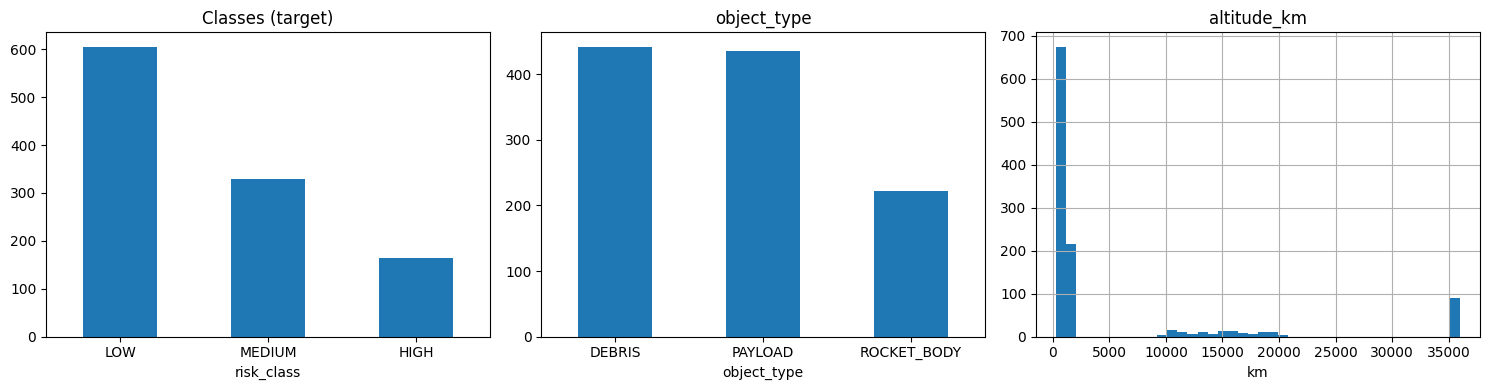

In [3]:
# === 2. EDA — distribuição das classes e estatísticas básicas ===
print("Balanço do target risk_class:")
print(df["risk_class"].value_counts(), "\n")
print("Nulos por coluna:")
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() else "Nenhum nulo.")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
df["risk_class"].value_counts().plot(kind="bar", ax=ax[0], title="Classes (target)", rot=0)
df["object_type"].value_counts().plot(kind="bar", ax=ax[1], title="object_type", rot=0)
df["altitude_km"].hist(bins=40, ax=ax[2]); ax[2].set_title("altitude_km"); ax[2].set_xlabel("km")
plt.tight_layout(); plt.show()

In [4]:
# === 3. Pré-processamento + feature engineering ===
# Drop de identificadores (não são features): object_id, object_name, epoch
DROP = ["object_id", "object_name", "epoch", "risk_class"]
TARGET = "risk_class"

# Feature engineering deliberada (justificativas no markdown abaixo):
df["log_rcs"] = np.log1p(df["rcs_value_m2"])                  # comprime cauda longa do RCS
df["altitude_band"] = pd.cut(df["altitude_km"],
                              bins=[0, 2000, 30000, 50000],
                              labels=["LEO", "MEO", "GEO"]).astype(str)   # regime orbital explícito

CAT_COLS = ["object_type", "rcs_size", "altitude_band"]
NUM_COLS = ["altitude_km", "inclination_deg", "eccentricity", "bstar",
            "rcs_value_m2", "log_rcs", "period_min", "days_in_orbit"]
FEATURES = CAT_COLS + NUM_COLS
print(f"{len(FEATURES)} features ({len(CAT_COLS)} categóricas + {len(NUM_COLS)} numéricas)")

X = df[FEATURES].copy(); y = df[TARGET].copy()

# Encoding: OrdinalEncoder funciona bem para árvores (sem explosão dimensional).
# Para rcs_size preservo a ordem SMALL < MEDIUM < LARGE explicitamente.
size_order = [["SMALL", "MEDIUM", "LARGE"]]

11 features (3 categóricas + 8 numéricas)


**Justificativas das features engineered (pontos de "engenharia de atributos"):**

- `log_rcs` — `rcs_value_m2` tem cauda longa (de 0.01 a ~50 m²). `log1p` comprime a escala e ajuda os modelos (sobretudo o linear) a fazer uso informativo da variável.
- `altitude_band` — codifica explicitamente o regime orbital (LEO/MEO/GEO), uma variável categórica que o modelo pode usar diretamente em vez de descobrir os limites por força bruta nos splits de `altitude_km`.

**Decisão de NÃO criar `is_maneuverable`:** a capacidade de manobra é função determinística de `object_type` (`PAYLOAD` manobra; `ROCKET_BODY`/`DEBRIS` não). Criar uma feature binária a partir disso apenas duplicaria o sinal já presente em `object_type` e inflaria artificialmente a importância no SHAP. Mantemos `object_type` como a única fonte desse sinal — interpretação mais limpa.

**Decisão de não dropar `period_min`:** `period_min` é colinear com `altitude_km` (terceira lei de Kepler), mas modelos baseados em árvore não sofrem com multicolinearidade. Mantemos ambos — a importância no SHAP será dividida entre os dois ("regime orbital").

In [5]:
# === 4. Split estratificado (preserva balanço HIGH/MEDIUM/LOW em treino e teste) ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED)
print("treino:", X_train.shape, "| teste:", X_test.shape)
print("balanço treino:", y_train.value_counts().to_dict())
print("balanço teste :", y_test.value_counts().to_dict())

treino: (825, 11) | teste: (275, 11)
balanço treino: {'LOW': 454, 'MEDIUM': 247, 'HIGH': 124}
balanço teste : {'LOW': 151, 'MEDIUM': 83, 'HIGH': 41}


In [6]:
# === 5. Pipelines de pré-processamento ===
# Árvores: OrdinalEncoder nas categóricas (sem one-hot, sem scaling — árvores não precisam).
# rcs_size com ordem explícita; object_type e altitude_band como ordinais simples.
def build_tree_pipeline(model):
    pre = ColumnTransformer(transformers=[
        ("rcs_ord", OrdinalEncoder(categories=size_order), ["rcs_size"]),
        ("cat_ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
                    ["object_type", "altitude_band"]),
    ], remainder="passthrough")
    return Pipeline([("pre", pre), ("clf", model)])

# Modelo linear: one-hot nas categóricas (sem ordem falsa) + StandardScaler nas numéricas.
# Pré-processamento próprio = comparação JUSTA (cada família recebe o tratamento adequado).
def build_linear_pipeline(model):
    pre = ColumnTransformer(transformers=[
        ("cat_oh", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
        ("num_sc", StandardScaler(), NUM_COLS),
    ])
    return Pipeline([("pre", pre), ("clf", model)])

pipe_rf = build_tree_pipeline(RandomForestClassifier(random_state=SEED, n_jobs=-1))
pipe_gb = build_tree_pipeline(GradientBoostingClassifier(random_state=SEED))
pipe_lr = build_linear_pipeline(LogisticRegression(max_iter=2000, random_state=SEED))

In [7]:
# === 6. GridSearchCV — comparação justa entre modelos ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_rf = GridSearchCV(pipe_rf, {
    "clf__n_estimators": [200, 400],
    "clf__max_depth":   [None, 15],
    "clf__min_samples_leaf": [1, 3],
}, cv=cv, scoring="accuracy", n_jobs=-1)

grid_gb = GridSearchCV(pipe_gb, {
    "clf__n_estimators":   [200, 400],
    "clf__max_depth":      [3, 5],
    "clf__learning_rate":  [0.05, 0.1],
}, cv=cv, scoring="accuracy", n_jobs=-1)

grid_lr = GridSearchCV(pipe_lr, {
    "clf__C": [0.1, 1.0, 10.0],
}, cv=cv, scoring="accuracy", n_jobs=-1)

for name, grid in [("RandomForest", grid_rf), ("GradientBoosting", grid_gb), ("LogisticRegression", grid_lr)]:
    print(f"Treinando {name}...")
    grid.fit(X_train, y_train)
    print(f"  melhor params: {grid.best_params_}")
    print(f"  CV mean acc:   {grid.best_score_:.3f}\n")

Treinando RandomForest...


  melhor params: {'clf__max_depth': None, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 400}
  CV mean acc:   0.853

Treinando GradientBoosting...


  melhor params: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 400}
  CV mean acc:   0.873

Treinando LogisticRegression...
  melhor params: {'clf__C': 10.0}
  CV mean acc:   0.714



=== RandomForest (tuned) ===
              precision    recall  f1-score   support

        HIGH      0.848     0.683     0.757        41
         LOW      0.935     0.954     0.944       151
      MEDIUM      0.773     0.819     0.795        83

    accuracy                          0.873       275
   macro avg      0.852     0.819     0.832       275
weighted avg      0.873     0.873     0.871       275

=== GradientBoosting (tuned) ===
              precision    recall  f1-score   support

        HIGH      0.784     0.707     0.744        41
         LOW      0.924     0.967     0.945       151
      MEDIUM      0.787     0.759     0.773        83

    accuracy                          0.865       275
   macro avg      0.832     0.811     0.821       275
weighted avg      0.862     0.865     0.863       275

=== LogisticRegression (tuned, baseline linear) ===
              precision    recall  f1-score   support

        HIGH      0.467     0.171     0.250        41
         LOW   

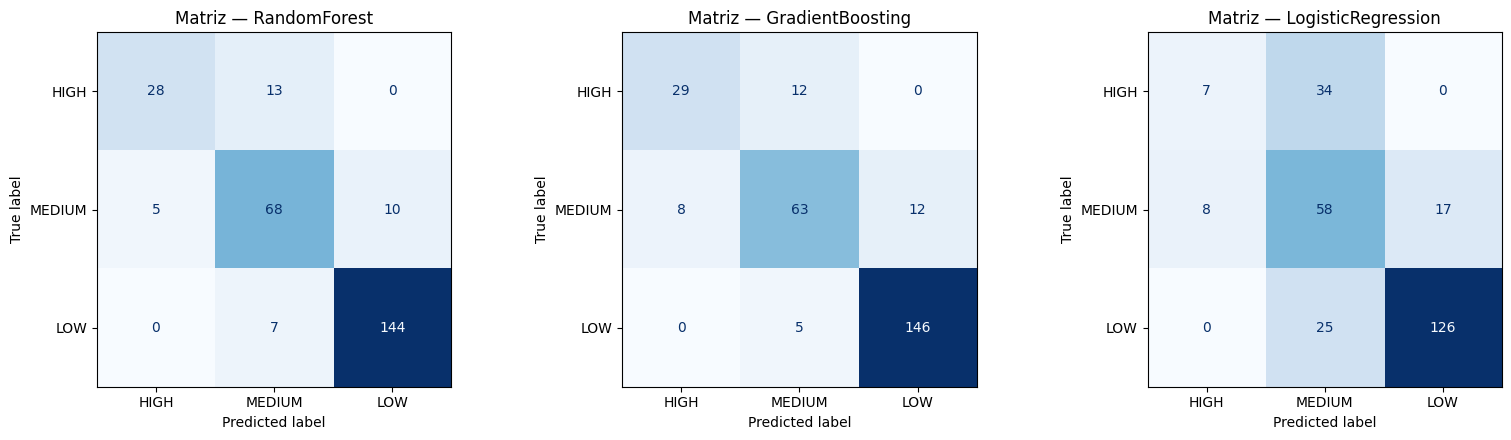

In [8]:
# === 7. Validação no teste — métricas por classe + matriz de confusão ===
labels = ["HIGH", "MEDIUM", "LOW"]

def evaluate(model, name):
    pred = model.predict(X_test)
    print(f"=== {name} ===")
    print(classification_report(y_test, pred, digits=3))
    return pred

pred_rf = evaluate(grid_rf.best_estimator_, "RandomForest (tuned)")
pred_gb = evaluate(grid_gb.best_estimator_, "GradientBoosting (tuned)")
pred_lr = evaluate(grid_lr.best_estimator_, "LogisticRegression (tuned, baseline linear)")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for a, p, nm in [(ax[0], pred_rf, "RandomForest"), (ax[1], pred_gb, "GradientBoosting"), (ax[2], pred_lr, "LogisticRegression")]:
    cm = confusion_matrix(y_test, p, labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=a, cmap="Blues", colorbar=False)
    a.set_title(f"Matriz — {nm}")
plt.tight_layout(); plt.show()

In [9]:
# === 8. ROC-AUC multi-classe (one-vs-rest) ===
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=labels)
for model, nm in [(grid_rf.best_estimator_, "RandomForest"),
                  (grid_gb.best_estimator_, "GradientBoosting"),
                  (grid_lr.best_estimator_, "LogisticRegression")]:
    proba = model.predict_proba(X_test)
    order = [list(model.classes_).index(c) for c in labels]   # alinha colunas de proba a labels
    auc = roc_auc_score(y_test_bin, proba[:, order], multi_class="ovr", average="macro")
    print(f"{nm}: ROC-AUC (macro OvR) = {auc:.3f}")

RandomForest: ROC-AUC (macro OvR) = 0.950
GradientBoosting: ROC-AUC (macro OvR) = 0.949
LogisticRegression: ROC-AUC (macro OvR) = 0.847


In [10]:
# === 9. Comparação final + modelo deployado/explicado ===
grids = {"RandomForest": grid_rf, "GradientBoosting": grid_gb, "LogisticRegression": grid_lr}
cv_scores = {k: g.best_score_ for k, g in grids.items()}
test_accs = {k: float((g.best_estimator_.predict(X_test) == y_test).mean()) for k, g in grids.items()}
macro_f1  = {k: f1_score(y_test, g.best_estimator_.predict(X_test), average="macro") for k, g in grids.items()}

print("CV acc:   ", {k: round(v, 3) for k, v in cv_scores.items()})
print("Test acc: ", {k: round(v, 3) for k, v in test_accs.items()})
print("Macro F1: ", {k: round(v, 3) for k, v in macro_f1.items()})

best_cv = max(cv_scores, key=cv_scores.get)
print(f"\nMelhor em CV: {best_cv}")

# Modelo deployado e explicado = RandomForest:
#  (1) está entre os melhores em CV/teste (árvores superam o baseline linear);
#  (2) o TreeExplainer fornece SHAP multiclasse EXATO para RandomForest — o
#      GradientBoostingClassifier multiclasse NÃO é suportado pelo TreeExplainer da lib,
#      então RF é a escolha que entrega interpretabilidade exata sem custo de desempenho.
deploy_name = "RandomForest"
deploy_model = grid_rf.best_estimator_
test_acc = test_accs[deploy_name]
print(f"Modelo deployado/explicado: {deploy_name} | CV = {cv_scores[deploy_name]:.3f} | test acc = {test_acc:.3f}")

CV acc:    {'RandomForest': np.float64(0.853), 'GradientBoosting': np.float64(0.873), 'LogisticRegression': np.float64(0.714)}
Test acc:  {'RandomForest': 0.873, 'GradientBoosting': 0.865, 'LogisticRegression': 0.695}
Macro F1:  {'RandomForest': 0.832, 'GradientBoosting': 0.821, 'LogisticRegression': 0.562}

Melhor em CV: GradientBoosting
Modelo deployado/explicado: RandomForest | CV = 0.853 | test acc = 0.873


## SHAP — interpretabilidade (10 pts da rubrica)

O SHAP responde a duas perguntas que a banca quer ver:

1. **Globalmente, o que dirige o modelo?** O `summary_plot` mostra a distribuição do impacto de cada feature sobre todas as predições. Esperamos ver `altitude_km`/`period_min` (regime orbital) e `object_type`/`rcs_value_m2` no topo.
2. **Por que o modelo deu *esta* resposta para *este* objeto?** O `waterfall_plot` decompõe uma predição individual em contribuições positivas/negativas de cada feature. Útil para justificar uma decisão a um operador ou auditoria.

/tmp/claude-501/ipykernel_34769/1553444935.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_pre, feature_names=feat_names,


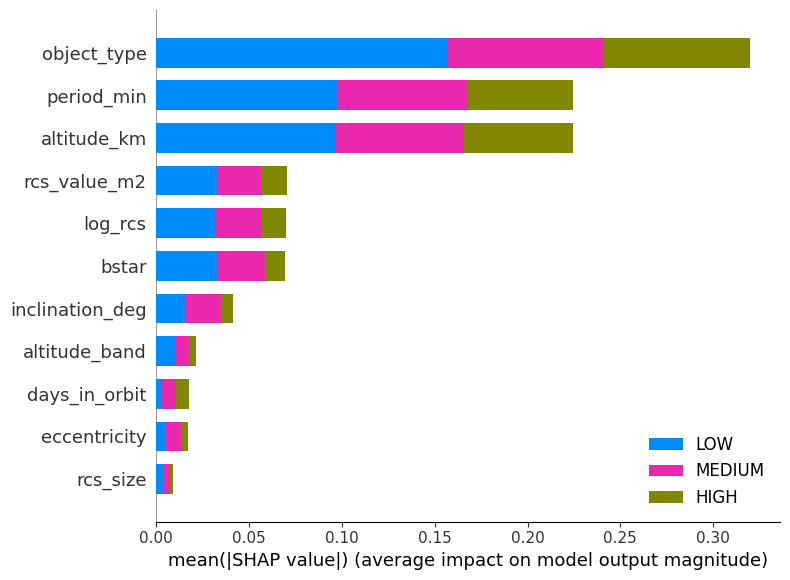

In [11]:
# === 10. SHAP global (summary_plot) ===
# TreeExplainer é o caminho rápido e exato para modelos baseados em árvore.
# Extraímos o classificador e o pré-processador do pipeline e operamos no espaço pré-processado
# (para que o SHAP veja as features na forma que o modelo realmente usou).
pre = deploy_model.named_steps["pre"]
clf = deploy_model.named_steps["clf"]

X_test_pre = pre.transform(X_test)
# Nomes das features após o ColumnTransformer das árvores:
# rcs_ord(rcs_size), cat_ord(object_type, altitude_band), passthrough(NUM_COLS)
feat_names = ["rcs_size", "object_type", "altitude_band"] + NUM_COLS

explainer = shap.TreeExplainer(clf)
shap_values = explainer(X_test_pre)   # Explanation; multiclass -> (n, n_features, n_classes)

shap.summary_plot(shap_values, X_test_pre, feature_names=feat_names,
                  class_names=list(clf.classes_), show=True)

In [12]:
# === 10b. SHAP global — importância média absoluta por feature (numérica, reproduzível) ===
# Torna rastreáveis os percentuais citados no README/discussão (em vez de só ler do gráfico).
mean_abs = np.abs(shap_values.values).mean(axis=0).mean(axis=1)   # média sobre amostras e classes
order = np.argsort(mean_abs)[::-1]
total = mean_abs.sum()
print("Importância global (mean|SHAP|, média entre classes):")
for i in order:
    print(f"  {feat_names[i]:18s} {mean_abs[i]:.4f}  ({100*mean_abs[i]/total:4.1f}%)")
regime = sum(mean_abs[feat_names.index(f)] for f in ["period_min", "altitude_km"])
print(f"\n  -> regime orbital (period_min+altitude_km) = {100*regime/total:.1f}% do total")

Importância global (mean|SHAP|, média entre classes):
  object_type        0.1067  (29.5%)
  period_min         0.0748  (20.7%)
  altitude_km        0.0748  (20.7%)
  rcs_value_m2       0.0235  ( 6.5%)
  log_rcs            0.0232  ( 6.4%)
  bstar              0.0231  ( 6.4%)
  inclination_deg    0.0138  ( 3.8%)
  altitude_band      0.0071  ( 2.0%)
  days_in_orbit      0.0059  ( 1.6%)
  eccentricity       0.0058  ( 1.6%)
  rcs_size           0.0030  ( 0.8%)

  -> regime orbital (period_min+altitude_km) = 41.4% do total


Objeto: {'object_name': 'ARIANE 5 R/B', 'object_type': 'ROCKET_BODY', 'altitude_km': 847.3, 'rcs_value_m2': 10.233}
Predição: HIGH


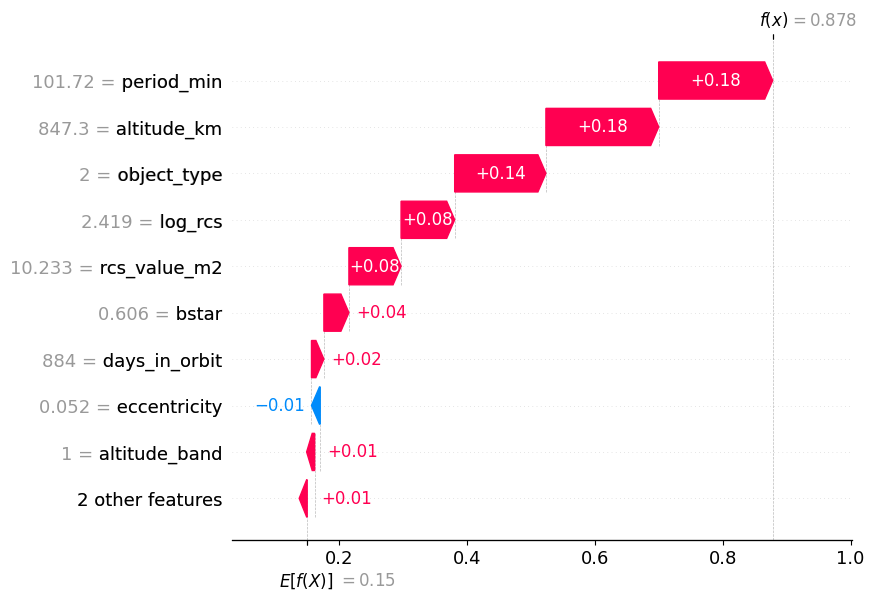

In [13]:
# === 11. SHAP local — waterfall de uma predição HIGH ===
# Pega o primeiro objeto do teste classificado como HIGH e explica a decisão.
pred_test = deploy_model.predict(X_test)
idx_high = np.where(pred_test == "HIGH")[0][0]
class_idx = list(clf.classes_).index("HIGH")

# API moderna: shap_values[i, :, c] para instância i, classe c
expl_high = shap.Explanation(
    values        = shap_values.values[idx_high, :, class_idx],
    base_values   = shap_values.base_values[idx_high, class_idx],
    data          = X_test_pre[idx_high],
    feature_names = feat_names,
)
print("Objeto:", df.iloc[X_test.index[idx_high]][["object_name","object_type","altitude_km","rcs_value_m2"]].to_dict())
print("Predição: HIGH")
shap.plots.waterfall(expl_high, show=True)

In [14]:
# === 12. Salva modelo + metadados + risk_scores.csv (handoff do data contract) ===
META = {
    "features": FEATURES,
    "cat_cols": CAT_COLS,
    "num_cols": NUM_COLS,
    "classes":  list(clf.classes_),
    "best":     deploy_name,
    "test_acc": float(test_acc),
}
joblib.dump(deploy_model, "gaie_risk_model.joblib")
with open("gaie_meta.json", "w") as f: json.dump(META, f, indent=2)

# Handoff HARD (data_contract.md): GAIE -> BDDI/SDTCC via risk_scores.csv (object_id, risk_class).
# Geramos a previsão para TODOS os objetos do dataset canônico.
X_all = df[FEATURES].copy()
risk_pred = deploy_model.predict(X_all)
risk_scores = pd.DataFrame({"object_id": df["object_id"], "risk_class": risk_pred})
risk_scores.to_csv("risk_scores.csv", index=False)
print("Salvos: gaie_risk_model.joblib + gaie_meta.json + risk_scores.csv")
print("risk_scores.csv:", risk_scores.shape, "| distribuição:", risk_scores["risk_class"].value_counts().to_dict())

# Em Colab: baixa os artefatos para você
try:
    from google.colab import files
    for fn in ["gaie_risk_model.joblib", "gaie_meta.json", "risk_scores.csv"]:
        files.download(fn)
except Exception:
    pass

Salvos: gaie_risk_model.joblib + gaie_meta.json + risk_scores.csv
risk_scores.csv: (1100, 2) | distribuição: {'LOW': 604, 'MEDIUM': 345, 'HIGH': 151}


## 13. Discussão (números reais desta execução, seed=42)

**Comparação final:**

| Modelo | CV acc (5-fold) | Test acc | Macro F1 | ROC-AUC (macro OvR) |
|---|---|---|---|---|
| RandomForest (tuned) | 0.853 | **0.873** | **0.832** | **0.950** |
| GradientBoosting (tuned) | **0.873** | 0.865 | 0.821 | 0.949 |
| LogisticRegression (baseline linear) | 0.714 | 0.695 | 0.562 | 0.847 |

**Modelo escolhido/deployado: RandomForest.** Justificativa: **maior acurácia no teste (0.873) e maior macro-F1 (0.832)**, ROC-AUC empatado no topo (0.950). O GradientBoosting teve CV marginalmente maior (0.873 vs 0.853), mas pior em teste e F1 — e o `TreeExplainer` não suporta `GradientBoostingClassifier` multiclasse, então RF entrega o melhor desempenho **com** SHAP exato. O baseline linear (LogReg) fica ~18 pontos abaixo: evidência de que a fronteira de decisão do problema é **não-linear**, justificando os modelos de árvore.

**O que o SHAP revela (mean|SHAP| medido, média entre classes):**

| Feature | Importância | |
|---|---|---|
| `object_type` | 29.5% | tipo do objeto (payload manobra; detrito/foguete não) |
| `period_min` + `altitude_km` | **41.4%** | **regime orbital** (colineares por Kepler — tratar como um bloco) |
| `rcs_value_m2` + `log_rcs` | ~13% | tamanho do objeto |
| demais (bstar, inclinação, etc.) | resto | contribuição menor |

Coerente com o `data_contract.md` (regime orbital ≈ 0.46, `object_type` ≈ 0.18, tamanho ≈ 0.11) e com a física: objetos não-manobráveis em bandas orbitais congestionadas e de maior tamanho concentram o risco `HIGH`. No waterfall individual (ex.: um `ROCKET_BODY` em ~847 km), `object_type` e o regime orbital empurram a predição para `HIGH`.

**Limitações declaradas:**
- O dataset é **sintético** (rótulo gerado por regra ruidosa). O modelo prova a **metodologia** (pipeline, comparação justa de 3 modelos com GridSearch, validação por classe + ROC-AUC, SHAP interpretável), não um classificador validado contra dados reais de TLE/conjunção. Trabalho futuro: validar com TLEs do CelesTrak e eventos de conjunção do SOCRATES.
- `altitude_km` e `period_min` são colineares; interpretar como "regime orbital".

## 14. README — texto base para o repositório

O `README.md` do repositório (gerado a partir deste texto) deve conter, no mínimo: contexto, dataset, metodologia, resultados (números reais), interpretação SHAP, instruções de execução, link da aplicação no ar, integrantes — e o diagrama-mestre do `data_contract.md` para evidenciar a coesão da Global Solution.